# Word2Vec 

"*Dime con quien andas y te diré quién eres*" - [Francisco de Quevedo en el siglo XVI](https://significalogia.com/dime-con-quien-andas-y-te-dire-quien-eres-significado-y-origen-de-este-refran/)
                                
*Word2Vec* es una técnica de **Procesamiento del Lenguaje Natural** (*NLP*) utilizada para representar palabras como vectores (en un **espacio continuo**) de características numéricas de baja dimensión. Este método, desarrollado por un equipo de Google dirigido por Tomas Mikolov en 2013, ha revolucionado la forma en que se representan las palabras en el espacio vectorial, permitiendo que las máquinas comprendan y procesen el texto de una manera más eficiente y efectiva.

*Word2Vec* utiliza dos arquitecturas principales para aprender las representaciones de las palabras:

1. **CBOW** (Continuous Bag of Words): Predice una palabra objetivo basada en su contexto circundante. Es decir, toma las palabras del contexto y trata de predecir la palabra central.
1. **Skip-gram**: Predice el contexto de una palabra objetivo. Toma una palabra central y trata de predecir las palabras circundantes en el contexto.

Ambos métodos se basan en redes neuronales simples y generan vectores de palabras que capturan las **relaciones semánticas** entre ellas.

El supuesto más importante de *Word2Vec* es que 2 palabras que tienen un **contexto similar**, entonces deben tener un **significado similar**, por ende, una representación vectorial similar.

Por ejemplo, palabras como "*perro*", "*cachorro*", "*mascota*" suelen estar en contextos similares, por ende su representación vectorial en *Word2Vec* debe ser similar. Es posible llegar a este tipo de conclusiones, gracias a que *Word2Vec* captura las relaciones semánticas entre palabras en base a los patrones descubiertos en la co-ocurrencia  de palabras dado un corpus.

# Load data

In [1]:
import itertools as it
from gensim.models.word2vec import LineSentence

c:\Users\eduardo.moreno\AppData\Local\anaconda3\envs\env_nlp\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


In [2]:
trigram_sentences_filepath = r'..\..\..\data\ngrams\fb-pages\trigram_sentences_all.txt'

In [3]:
trigram_sentences = LineSentence(trigram_sentences_filepath)

Algunos mensajes preprocesados son:

In [4]:
for trigram_sentence in it.islice(trigram_sentences, 123, 128):
    print(' '.join(trigram_sentence))
    print('')

necesario ejercer medida tangible disminuir emanacion gas_efecto_invernadero afectar temperatura global transporte automotriz aportar 23 gas_contaminante imperante reducir transporte utilizar combustible_fosil razon buscar modificar ley federal servidor_publico promover distancia objetivo reducir utilizacion transporte automotriz empleado gubernamental objetivo mejorar movilidad grande ciudad reducir afluencia persona movilizar simultaneamente hora pico producir trafico vehicular medida reducir tangiblemente transporte contaminante beneficiar forma calidad_vida empleado

mexico requerira 12900 mdd prevenir cambio climatico

lider_mundial regalar cambio climatico injusticia fiscal malnutricion abandono escolar inspiraction querer cambiar mundo mas justo sostenible respetar derechos_humanos navidad regalar solidaridad

bici bambu pedalear idea verde

impresionante imagen deshielo_artico producir canibalismo imagen impresionar revelar consecuencia cambio climatico oso_polar limitado coto 

# Word2Vec

## CBOW

In [5]:
import multiprocessing
from gensim.models import Word2Vec

In [6]:
cores = multiprocessing.cpu_count()
print(f"Number of cores available: {cores}")

Number of cores available: 16


Definir el modelo

In [7]:
%%time
if 1 == 1:
    # Definir modelo
    w2v_model = Word2Vec(
        min_count=200,
        window=3,
        #sample=6e-5, 
        alpha=0.05, 
        #min_alpha=0.0007, 
        #negative=20,
        vector_size=400,
        workers=cores-1,
        sg=1,
        seed=42,
    )
    # Construir vocabulario
    w2v_model.build_vocab(
        trigram_sentences, 
        progress_per=10000
    )
    # Entrenar el modelo
    w2v_model.train(
        trigram_sentences, 
        total_examples=w2v_model.corpus_count, 
        epochs=30, 
        report_delay=15
    )
    w2v_model.save(r"..\..\models\w2v\w2v-cbow-fb-pages.model")
else:
    w2v_model = Word2Vec.load(r"..\..\models\w2v\w2v-cbow-fb-pages.model")

CPU times: total: 4h 30min 25s
Wall time: 22min 13s


Comportamiento

In [8]:
similar_words = w2v_model.wv.most_similar(positive=["clima"])
for word, similarity in similar_words:
    print(f"{word}: {similarity}")

climatica: 0.3995230495929718
climatico: 0.3503745496273041
cambioclimatico: 0.3470238447189331
meteorologia: 0.3163321018218994
temperatura: 0.29390257596969604
climatologia: 0.2818510830402374
fenomeno_meteorologicos: 0.2814808487892151
climate: 0.28046324849128723
clima_cambiante: 0.27979737520217896
climatologica: 0.27909356355667114


In [9]:
w2v_model.wv.most_similar(positive=["cambio"])

[('climatico', 0.5789062976837158),
 ('cambioclimatico', 0.48743462562561035),
 ('calentamiento_global', 0.4589826762676239),
 ('crisis', 0.4158392548561096),
 ('efecto', 0.3734392523765564),
 ('fenomeno', 0.3245789110660553),
 ('impacto', 0.32038649916648865),
 ('emergencia', 0.3190440237522125),
 ('enterate', 0.3005486726760864),
 ('ambiental', 0.2958623170852661)]

In [11]:
w2v_model.wv.most_similar(positive=["climatico"])

[('cambio', 0.5789062976837158),
 ('cambioclimatico', 0.49354392290115356),
 ('calentamiento_global', 0.4672618508338928),
 ('efecto', 0.3787071108818054),
 ('clima', 0.35037460923194885),
 ('ambiental', 0.3170935809612274),
 ('climatica', 0.3153010606765747),
 ('impacto', 0.29769089818000793),
 ('enterate', 0.2955513894557953),
 ('fenomeno', 0.2938954532146454)]

In [12]:
w2v_model.wv.most_similar(positive=["medio_ambiente"])

[('medioambiente', 0.5494529604911804),
 ('ambiente', 0.5202395915985107),
 ('cuidado_medio_ambiente', 0.4644111394882202),
 ('recurso_natural', 0.3660085201263428),
 ('ambiental', 0.3621520698070526),
 ('medioambiental', 0.3494272530078888),
 ('ecologia', 0.3473886549472809),
 ('entorno_natural', 0.3368391692638397),
 ('desarrollo_sustentable', 0.3225606679916382),
 ('entorno', 0.3212830126285553)]

In [13]:
w2v_model.wv.most_similar(positive=["agua"])

[('agua_potable', 0.5192971229553223),
 ('vital_liquido', 0.5044372081756592),
 ('recurso_hidrico', 0.4814734160900116),
 ('liquido', 0.4811078906059265),
 ('agua_dulce', 0.4801398515701294),
 ('liquido_vital', 0.471051424741745),
 ('agua_superficial', 0.4145449697971344),
 ('acuifero', 0.41418275237083435),
 ('agua_subterraneo', 0.4140177071094513),
 ('agua_subterranea', 0.40114933252334595)]

In [14]:
w2v_model.wv.most_similar(positive=["sol"])

[('rayo_sol', 0.43290528655052185),
 ('radiacion', 0.42868727445602417),
 ('luz_solar', 0.42556124925613403),
 ('rayo_solar', 0.4196820855140686),
 ('radiacion_solar', 0.40167537331581116),
 ('solar', 0.37789568305015564),
 ('viento', 0.37248238921165466),
 ('rayo', 0.3677414655685425),
 ('astro', 0.3655281364917755),
 ('luz_sol', 0.36021217703819275)]

In [15]:
w2v_model.wv.most_similar(positive=["desastre"])

[('desastre_natural', 0.6365634202957153),
 ('catastrof', 0.5804960131645203),
 ('catastrofe', 0.5065356492996216),
 ('tragedia', 0.498980313539505),
 ('emergencia', 0.4377628266811371),
 ('catastrofes', 0.4368305504322052),
 ('fenomeno_natural', 0.4291338324546814),
 ('calamidad', 0.4199827015399933),
 ('inundacion', 0.4071396589279175),
 ('catastrof_natural', 0.4024159908294678)]

In [16]:
w2v_model.wv.most_similar(positive=["desastre_natural"])

[('desastre', 0.6365634202957153),
 ('catastrof', 0.5201606750488281),
 ('catastrof_natural', 0.496698796749115),
 ('fenomeno_natural', 0.4841574728488922),
 ('evento_meteorologico_extremo', 0.4391044080257416),
 ('terremoto', 0.4376453459262848),
 ('fenomeno_meteorologico_extremo', 0.4364086091518402),
 ('fenomeno_meteorologicos', 0.42825883626937866),
 ('inundacion', 0.425629585981369),
 ('huracan', 0.4249567687511444)]

In [17]:
w2v_model.wv.most_similar(positive=["incremento"])

[('aumento', 0.848302960395813),
 ('incrementar', 0.5976297855377197),
 ('disminucion', 0.5857273936271667),
 ('aumentar', 0.5585804581642151),
 ('alza', 0.4958224594593048),
 ('descenso', 0.47160452604293823),
 ('reduccion', 0.4696679413318634),
 ('aumento_temperatura', 0.42980703711509705),
 ('duplicar', 0.4207322597503662),
 ('creciente', 0.4189924895763397)]

In [18]:
w2v_model.wv.most_similar(positive=["temperatura"])

[('aumento_temperatura', 0.6676660776138306),
 ('temperatura_promedio', 0.654190719127655),
 ('alto_temperatura', 0.6488462686538696),
 ('grado_centigrado', 0.6455181837081909),
 ('incremento_temperatura', 0.6246713995933533),
 ('grado_celsius', 0.6112966537475586),
 ('temperatura_maxima', 0.5937192440032959),
 ('calor', 0.5630370378494263),
 ('degc', 0.5547250509262085),
 ('oc', 0.5543836355209351)]

In [19]:
w2v_model.wv.most_similar(positive=["bajar"])

[('subir', 0.5452678203582764),
 ('descender', 0.4885474741458893),
 ('disminuir', 0.4495405852794647),
 ('reducir', 0.4161556661128998),
 ('rebajar', 0.41539856791496277),
 ('elevado', 0.40105798840522766),
 ('elevar', 0.3963831961154938),
 ('caer', 0.3943946361541748),
 ('descenso', 0.39341017603874207),
 ('bajada', 0.38791200518608093)]

In [20]:
w2v_model.wv.most_similar(positive=["mas"])

[('extremadamente', 0.3882662057876587),
 ('demasiado', 0.3788125813007355),
 ('sumamente', 0.3478420674800873),
 ('relativamente', 0.33368155360221863),
 ('particularmente', 0.3317282199859619),
 ('mundo', 0.3307422697544098),
 ('increiblemente', 0.32103022933006287),
 ('altamente', 0.3096570074558258),
 ('especialmente', 0.3066468834877014),
 ('suficientemente', 0.3051905035972595)]

In [21]:
w2v_model.wv.most_similar(positive=["gobierno"])

[('gobierno_federal', 0.43674033880233765),
 ('administracion', 0.43133804202079773),
 ('gubernamental', 0.4055635631084442),
 ('mandatario', 0.4033263325691223),
 ('ejecutivo', 0.38685712218284607),
 ('autoridad', 0.37522459030151367),
 ('gobernador', 0.34845179319381714),
 ('gobernante', 0.3474620282649994),
 ('presidente', 0.34656086564064026),
 ('electo', 0.33638620376586914)]

Similitud entre 2 tokens:

In [22]:
w2v_model.wv.similarity("incrementar", "temperatura")

0.18397716

In [23]:
w2v_model.wv.similarity("disminuir", "temperatura")

0.23103645

## Skip Gram

In [24]:
%%time
if 1 == 1:
    w2v_model_sg = Word2Vec(
        min_count=200,
        window=3,
        #sample=6e-5, 
        alpha=0.05, 
        #min_alpha=0.0007, 
        #negative=20,
        vector_size=400,
        workers=cores-1,
        sg=1,
        seed=42,
    )

    w2v_model_sg.build_vocab(
        trigram_sentences, 
        progress_per=10000
    )

    w2v_model_sg.train(
        trigram_sentences, 
        total_examples=w2v_model_sg.corpus_count, 
        epochs=30, 
        report_delay=15
    )
    w2v_model_sg.save(r"..\..\models\w2v\w2v-sg-fb-pages.model")
else:
    w2v_model_sg = Word2Vec.load(r"..\..\models\w2v\w2v-sg-fb-pages.model")

CPU times: total: 4h 51min 4s
Wall time: 22min 9s


In [25]:
similar_words = w2v_model_sg.wv.most_similar(positive=["clima"])
for word, similarity in similar_words:
    print(f"{word}: {similarity}")

climatica: 0.3980334997177124
cambioclimatico: 0.34833046793937683
climatico: 0.3461287319660187
meteorologia: 0.31447988748550415
temperatura: 0.30914685130119324
climatologia: 0.303940087556839
climatologica: 0.278968870639801
calentamientoglobal: 0.27138787508010864
accion_climatica: 0.2696932554244995
fenomeno_meteorologicos: 0.26348206400871277


In [26]:
w2v_model_sg.wv.most_similar(positive=["cambio"])

[('climatico', 0.5908337235450745),
 ('cambioclimatico', 0.49239590764045715),
 ('calentamiento_global', 0.4530920684337616),
 ('crisis', 0.41450393199920654),
 ('efecto', 0.37791359424591064),
 ('fenomeno', 0.3269374370574951),
 ('impacto', 0.3192754089832306),
 ('emergencia', 0.30716729164123535),
 ('efecto_negativo', 0.29152923822402954),
 ('desertificacion', 0.28786587715148926)]

In [27]:
w2v_model_sg.wv.most_similar(positive=["climatico"])

[('cambio', 0.590833842754364),
 ('cambioclimatico', 0.4944772720336914),
 ('calentamiento_global', 0.47032883763313293),
 ('efecto', 0.3664710819721222),
 ('clima', 0.34612876176834106),
 ('climatica', 0.3221378028392792),
 ('ambiental', 0.3167036473751068),
 ('impacto', 0.3075854480266571),
 ('enterate', 0.30373382568359375),
 ('efecto_adverso', 0.28955432772636414)]

In [28]:
w2v_model_sg.wv.most_similar(positive=["medio_ambiente"])

[('medioambiente', 0.541800856590271),
 ('ambiente', 0.5172749161720276),
 ('cuidado_medio_ambiente', 0.4651429355144501),
 ('recurso_natural', 0.37395739555358887),
 ('entorno_natural', 0.35962530970573425),
 ('ambiental', 0.3556036949157715),
 ('ecologia', 0.32878607511520386),
 ('titular_secretaria_medio_ambiente', 0.32856565713882446),
 ('medioambiental', 0.32556062936782837),
 ('educacion_ambiental', 0.3247429430484772)]

In [29]:
w2v_model_sg.wv.most_similar(positive=["agua"])

[('agua_potable', 0.5454285740852356),
 ('recurso_hidrico', 0.4983692169189453),
 ('liquido', 0.49198371171951294),
 ('vital_liquido', 0.4916437864303589),
 ('agua_dulce', 0.4750075340270996),
 ('liquido_vital', 0.471493124961853),
 ('agua_superficial', 0.420545756816864),
 ('acuifero', 0.41991928219795227),
 ('agua_subterraneo', 0.41930603981018066),
 ('agua_subterranea', 0.40182384848594666)]

In [30]:
w2v_model_sg.wv.most_similar(positive=["mas"])

[('demasiado', 0.3906736969947815),
 ('extremadamente', 0.384380042552948),
 ('sumamente', 0.3622031807899475),
 ('mundo', 0.3402082324028015),
 ('increiblemente', 0.32590246200561523),
 ('relativamente', 0.3222428858280182),
 ('altamente', 0.3209148943424225),
 ('particularmente', 0.3176434636116028),
 ('realmente', 0.31593331694602966),
 ('suficientemente', 0.30828025937080383)]

In [31]:
w2v_model_sg.wv.most_similar(positive=["ano"])

[('anos', 0.5877568125724792),
 ('mes', 0.5487074255943298),
 ('decada', 0.5176259875297546),
 ('2020', 0.4634173810482025),
 ('2019', 0.4575192928314209),
 ('2021', 0.44430994987487793),
 ('2018', 0.43190932273864746),
 ('2017', 0.41099998354911804),
 ('periodo', 0.41026344895362854),
 ('enero', 0.4051971435546875)]

In [32]:
w2v_model_sg.wv.most_similar(positive=["gobierno"])

[('gobierno_federal', 0.4345656633377075),
 ('administracion', 0.42373907566070557),
 ('gubernamental', 0.39714953303337097),
 ('mandatario', 0.3960351049900055),
 ('autoridad', 0.38014575839042664),
 ('ejecutivo', 0.3784111738204956),
 ('gobernante', 0.3548603653907776),
 ('gobernador', 0.3499017357826233),
 ('funcionario', 0.34611067175865173),
 ('presidente', 0.3347984850406647)]

# T-SNE

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

In [35]:
words = ["agua", "clima", "medio_ambiente", "paris", "climatico", "falta", "nube", "peligro", "recurso", "acuerdo", "america", "unido", "ley", "temperatura", "frio", "calor"]
print(f"Numero de palabras {len(words)}")
word_vectors = [w2v_model_sg.wv[word] for word in words]
word_vectors = np.array(word_vectors)

Numero de palabras 16


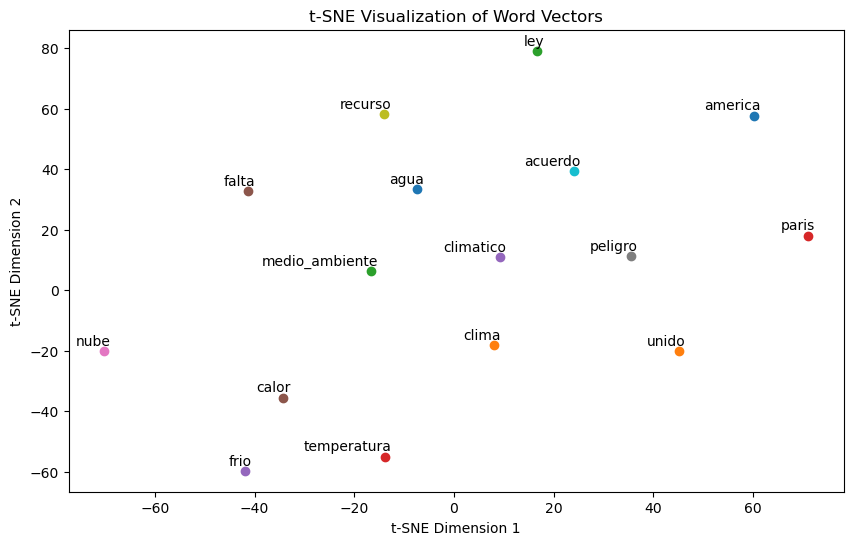

In [36]:
tsne_model = TSNE(n_components=2, random_state=42, perplexity=10)
tsne_vectors = tsne_model.fit_transform(word_vectors)

plt.figure(figsize=(10, 6))
for i, word in enumerate(words):
    plt.scatter(tsne_vectors[i, 0], tsne_vectors[i, 1])
    plt.annotate(word, xy=(tsne_vectors[i, 0], tsne_vectors[i, 1]), xytext=(5, 2), textcoords='offset points', ha='right', va='bottom')

plt.title('t-SNE Visualization of Word Vectors')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()